In [1]:
round_wise_data = []
from tqdm import tqdm
for round in tqdm(range(1, 30)):
    # file = f'/scratch/ps9044/newsetting/expguardtrainsafe5_expguardtrain5_500_safelorav2data_c10s10_i10_b16a1_l512_r32a64_20260517123541/round_{round}.pkl'
    file = f'/scratch/ps9044/newsetting/BeaverTailsSafe5_BeaverTails5_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260517123537/round_{round}.pkl'

    

100%|██████████| 29/29 [00:00<00:00, 460737.94it/s]


In [38]:
import os
import pickle
import re
import torch
import numpy as np
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import json

# Config
BASE_MODEL = "meta-llama/Llama-2-7b-chat-hf"
ROOT_DIR = '/scratch/ps9044/newsetting/expguardtrainsafe5_expguardtrain5_500_safelorav2data_c10s10_i10_b16a1_l512_r32a64_20260517123541'
# ROOT_DIR = '/scratch/ps9044/newsetting/BeaverTailsSafe5_BeaverTails5_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260517123537'
# ROOT_DIR = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20260212170509'
# SAFETY_DATASET_NAME = 'oneshotharm'
SAFETY_DATASET_NAME = 'oneshotrandom'

HF_TOKEN = os.environ.get('HUGGINGFACE_HUB_TOKEN')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [39]:
print("Loading base Llama model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    device_map='cuda:1',
    use_auth_token=HF_TOKEN,
    torch_dtype=torch.float16,
)
tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL,
    use_auth_token=HF_TOKEN,
    padding_side='right'
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.unk_token
print(f"Base model loaded. Device map: {getattr(base_model, 'hf_device_map', None)}")

Loading base Llama model...


Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.97s/it]
Using pad_token, but it is not set yet.


Base model loaded. Device map: {'': device(type='cuda', index=1)}


In [40]:
import sys
sys.path.insert(0, '/home/ps9044/RPA/fedllm-attack')
from utils.process_dataset import process_sft_dataset, get_whole_dataset

safety_dataset = process_sft_dataset(
    SAFETY_DATASET_NAME,
    get_whole_dataset(SAFETY_DATASET_NAME, '/home/ps9044/RPA/fedllm-attack/'),
    'chat',
    1,
    False,
    tokenizer=tokenizer,
)
print(f"Safety dataset loaded: {len(safety_dataset)} examples")


def _example_to_text(example):
    if "formatted_chat" in example:
        return example["formatted_chat"]
    instruction = example.get("instruction", "")
    response = example.get("response", "")
    inp = example.get("input", "")
    if inp:
        instruction = f"{instruction}\n{inp}"
    return f"### Instruction:\n{instruction}\n\n### Response:\n{response}"

>> ===== After processing, Dataset oneshotrandom has 1 examples. =====
Safety dataset loaded: 1 examples


In [41]:
def _normalize_param_name(name):
    # Remove PEFT prefixes
    if name.startswith("base_model.model."):
        name = name[len("base_model.model."):]
    elif name.startswith("base_model."):
        name = name[len("base_model."):]

    # Collapse duplicate model prefix
    # model.model.layers... -> model.layers...
    if name.startswith("model.model."):
        name = "model." + name[len("model.model."):]

    # Collapse repeatedly, just in case
    while name.startswith("model.model."):
        name = "model." + name[len("model.model."):]

    # PEFT base-layer naming
    name = name.replace(".base_layer.weight", ".weight")

    return name

def _get_lora_scale_from_model(model):
    peft_cfg = getattr(model, "peft_config", None)
    if not peft_cfg:
        return None
    cfg = next(iter(peft_cfg.values()))
    r = getattr(cfg, "r", None)
    alpha = getattr(cfg, "lora_alpha", None)
    if r is None or alpha is None:
        return None
    if r == 0:
        return None
    return float(alpha) / float(r)


def _get_lora_scale_from_path(path):
    match = re.search(r"_r(\d+)a(\d+)_", path)
    if not match:
        return None
    r = float(match.group(1))
    alpha = float(match.group(2))
    if r == 0:
        return None
    return alpha / r


def compute_safety_gradient_full_weights(model, tokenizer, safety_texts, max_length=512):
    """
    Compute gradients on base q_proj and v_proj full weights.
    LoRA parameters stay frozen; LoRA still affects the forward pass.
    Returns dict: {param_name: gradient_tensor}
    """
    for param in model.parameters():
        param.requires_grad_(False)

    target_params = {}
    for name, param in model.named_parameters():
        if 'lora' in name:
            continue
        if any(target in name for target in ['q_proj', 'v_proj']) and param.ndim == 2:
            param.requires_grad_(True)
            norm_name = _normalize_param_name(name)
            target_params[norm_name] = param

    if len(target_params) == 0:
        raise ValueError("No q_proj/v_proj base parameters found for full-weight gradient computation.")

    grad_acc = {
        name: torch.zeros_like(param, dtype=torch.float32, device='cpu')
        for name, param in target_params.items()
    }

    model_device = next(model.parameters()).device
    num_batches = 0

    for text in safety_texts:
        full_text = text
        response_start_marker = "[/INST]"
        cutoff_char = full_text.index(response_start_marker) + len(response_start_marker)

        prompt_text = full_text[:cutoff_char]
        response_text = full_text[cutoff_char:]

        # print("PROMPT:")
        # print(prompt_text)

        # print("\nRESPONSE:")
        # print(response_text)

        prompt_ids = tokenizer(
            [prompt_text],
            return_tensors="pt",
            truncation=True,
            max_length=max_length,
            add_special_tokens=False,
        )["input_ids"]

        encoded = tokenizer(
            [full_text],
            return_tensors="pt",
            truncation=True,
            max_length=max_length,
            padding=True,
            add_special_tokens=False,
        ).to(model_device)

        input_ids = encoded["input_ids"]
        attention_mask = encoded["attention_mask"]

        labels = input_ids.clone()

        prompt_len = prompt_ids.shape[1]

        # Ignore instruction/system/user tokens
        labels[:, :prompt_len] = -100

        # print("LOSS PART:")
        # print(tokenizer.decode(input_ids[0][prompt_len:]))


        # encoded = tokenizer(
        #     [text],
        #     truncation=True,
        #     max_length=max_length,
        #     padding=True,
        #     return_tensors='pt',
        # )
        # encoded = {k: v.to(model_device) for k, v in encoded.items()}
        # labels = encoded['input_ids'].clone()
        if 'attention_mask' in encoded:
            labels[encoded['attention_mask'] == 0] = -100

        if not hasattr(compute_safety_gradient_full_weights, "_checked"):
            compute_safety_gradient_full_weights._checked = True
            input_ids = encoded['input_ids']
            min_id = int(input_ids.min().item())
            max_id = int(input_ids.max().item())
            vocab_size = int(getattr(model.config, 'vocab_size', -1))
            print(f"[debug] token id range: {min_id}..{max_id} | vocab_size={vocab_size}")
            if vocab_size > 0 and (min_id < 0 or max_id >= vocab_size):
                raise ValueError(
                    f"Token ids out of range: min={min_id} max={max_id} vocab_size={vocab_size}"
                )

        model.zero_grad(set_to_none=True)
        outputs = model(**encoded, labels=labels)
        loss = outputs.loss
        loss.backward()

        for name, param in target_params.items():
            if param.grad is not None:
                grad_acc[name] += param.grad.detach().float().cpu()

        num_batches += 1
        del loss, outputs, labels, encoded
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if num_batches > 0:
        for name in grad_acc:
            grad_acc[name] /= num_batches

    model.zero_grad(set_to_none=True)
    return grad_acc

In [42]:
def reconstruct_full_weight_delta(lora_dict_local, lora_dict_global, base_state_dict, lora_scale=1.0):
    """
    Reconstruct ΔW = W_merged_local - W_merged_global for q_proj and v_proj.
    
    Returns dict: {param_name: delta_weight}
    """
    deltas = {}
    lora_scale = float(lora_scale)
    # print(lora_dict_local.keys())
    # For each q_proj and v_proj in the base model
    for name, base_param in base_state_dict.items():
        if not any(target in name for target in ['q_proj', 'v_proj']):
            continue
        if 'weight' not in name:
            continue
        
        # Corresponding LoRA A and B names
        # e.g., "model.layers.0.self_attn.q_proj.weight" -> find "layers.0.self_attn.q_proj.lora_A.weight"
        layer_info = name.replace('.weight', '')
        # lora_a_name = layer_info.replace('model.', 'base_model.model.') + '.lora_A.weight'
        # lora_b_name = layer_info.replace('model.', 'base_model.model.') + '.lora_B.weight'
        layer_name = name.removesuffix(".weight")
        lora_a_name = f"base_model.model.{layer_name}.lora_A.weight"
        lora_b_name = f"base_model.model.{layer_name}.lora_B.weight"
        
        # # Try variants
        # if lora_a_name not in lora_dict_local:
        #     # Try without 'base_model.model.' prefix
        #     lora_a_name = layer_info + '.lora_A.weight'
        #     lora_b_name = layer_info + '.lora_B.weight'
        
        if lora_a_name not in lora_dict_local or lora_b_name not in lora_dict_local:
            print("not here please")
            continue
        
        try:
            # Get LoRA params
            A_local = lora_dict_local[lora_a_name]
            B_local = lora_dict_local[lora_b_name]
            A_global = lora_dict_global[lora_a_name]
            B_global = lora_dict_global[lora_b_name]
            
            # Move to same device
            device_target = 'cpu'
            A_local = A_local.to(device_target)
            B_local = B_local.to(device_target)
            A_global = A_global.to(device_target)
            B_global = B_global.to(device_target)
            
            # Reconstruct full updates: ΔW = (alpha/r) * (B @ A)
            delta_local = lora_scale * torch.mm(B_local, A_local)
            delta_global = lora_scale * torch.mm(B_global, A_global)
            
            # Store the difference
            deltas[name] = (delta_local - delta_global).float()
        except Exception as e:
            print(f"Warning: could not reconstruct delta for {name}: {e}")
            continue
    
    return deltas

In [43]:
round_analysis = []
lora_scale = _get_lora_scale_from_path(ROOT_DIR)
if lora_scale is None:
    lora_scale = 1.0
    print("[warn] Could not parse LoRA scale from ROOT_DIR; defaulting to 1.0")

for round_num in tqdm(range(1, 3)):
    round_data = {
        'round': round_num,
        'clients': [],
    }
    
    # Load checkpoint for this round's deltas
    if round_num == 1:
        print(f"\n[Round {round_num}] Using base model (pre-merge for round 1)")
        model = base_model
        round_data['base_model'] = True
    else:
        # For round N deltas, use checkpoint-(N-1) (post-merge from previous round)
        checkpoint_path = os.path.join(ROOT_DIR, f'checkpoint-{round_num - 1}')
        if not os.path.exists(checkpoint_path):
            print(f"Checkpoint {checkpoint_path} not found, skipping")
            continue
        
        print(f"\n[Round {round_num}] Loading PEFT from {checkpoint_path}")
        model = AutoModelForCausalLM.from_pretrained(
            BASE_MODEL,
            device_map='cuda:1',
            use_auth_token=HF_TOKEN,
            torch_dtype=torch.float16,
        )
        model = PeftModel.from_pretrained(model, checkpoint_path, is_trainable=False)
        round_data['base_model'] = False
        
        model_scale = _get_lora_scale_from_model(model)
        if model_scale is not None and abs(model_scale - lora_scale) > 1e-9:
            lora_scale = model_scale
            print(f"[info] Using LoRA scale from checkpoint: {lora_scale:.6f}")
    
    model.eval()
    
    # Compute safety gradient on base weights with LoRA active (no merge)
    safety_texts = [_example_to_text(safety_dataset[0])]
    safety_grad = compute_safety_gradient_full_weights(model, tokenizer, safety_texts)
    round_data['safety_gradient_norms'] = {
        name: float(torch.norm(g).item()) for name, g in safety_grad.items()
    }
    safety_keys = set(safety_grad.keys())
    
    # Load pkl file for this round to get local_dict_list and global_dict
    pkl_path = os.path.join(ROOT_DIR, f'round_{round_num}.pkl')
    if not os.path.exists(pkl_path):
        print(f"PKL {pkl_path} not found, skipping delta computation")
        continue
    
    with open(pkl_path, 'rb') as f:
        pkl_data = pickle.load(f)
    
    global_dict = pkl_data['global_dict']
    local_dict_list = pkl_data['local_dict_list']
    
    # Get base state dict (for parameter name mapping)
    base_state = {name: param for name, param in base_model.named_parameters()}
    # Compute delta for each client
    for client_idx, local_dict in enumerate(local_dict_list):
        try:
            deltas = reconstruct_full_weight_delta(local_dict, global_dict, base_state, lora_scale=lora_scale)
            
            client_data = {
                'client': client_idx,
                'delta_norms': {},
                'gradient_norms': {},
                'cosine_similarity': {},
            }
            match_count = 0

            # if round_num > 1:
            #     print("Delta Keys:")
            #     print(deltas.keys())
                
            #     print("Safety Keys:")
            #     print(safety_keys)
            
            for param_name, delta_w in deltas.items():
                client_data['delta_norms'][param_name] = float(torch.norm(delta_w).item())
                
                # Find corresponding safety gradient
                if param_name in safety_keys:
                    # if round_num > 1:
                    #     print("here matched")
                    grad = safety_grad[param_name].to('cpu')
                    client_data['gradient_norms'][param_name] = float(torch.norm(grad).item())
                    
                    # Cosine similarity
                    cos_sim = float(
                        torch.nn.functional.cosine_similarity(
                            delta_w.reshape(1, -1),
                            grad.reshape(1, -1)
                        ).item()
                    )
                    client_data['cosine_similarity'][param_name] = cos_sim
                    match_count += 1
            
            client_data['match_count'] = match_count
            round_data['clients'].append(client_data)
        except Exception as e:
            print(f"Error processing client {client_idx} in round {round_num}: {e}")
            continue
    
    if round_data['clients']:
        match_counts = [c['match_count'] for c in round_data['clients']]
        if max(match_counts) == 0:
            print(f"[warn] Round {round_num}: no matching gradient/delta keys (check name normalization).")
    
    round_analysis.append(round_data)
    print(f"Round {round_num}: proces/sed {len(round_data['clients'])} clients")
    del model
print("\n✓ Analysis complete")

  0%|          | 0/2 [00:00<?, ?it/s]


[Round 1] Using base model (pre-merge for round 1)
[debug] token id range: 1..29973 | vocab_size=32000


 50%|█████     | 1/2 [00:56<00:56, 56.84s/it]

Round 1: proces/sed 10 clients

[Round 2] Loading PEFT from /scratch/ps9044/newsetting/expguardtrainsafe5_expguardtrain5_500_safelorav2data_c10s10_i10_b16a1_l512_r32a64_20260517123541/checkpoint-1


100%|██████████| 2/2 [02:10<00:00, 65.13s/it]

Round 2: proces/sed 10 clients

✓ Analysis complete


In [44]:
summary_rows = []
for round_data in round_analysis:
    round_num = round_data['round']
    for client_data in round_data['clients']:
        client_idx = client_data['client']
        
        # Average metrics across all q/v projections
        delta_norms = list(client_data['delta_norms'].values())
        grad_norms = list(client_data['gradient_norms'].values())
        cos_sims = list(client_data['cosine_similarity'].values())
        
        if delta_norms and grad_norms and cos_sims:
            summary_rows.append({
                'round': round_num,
                'client': client_idx,
                'avg_delta_norm': np.mean(delta_norms),
                'avg_grad_norm': np.mean(grad_norms),
                'avg_cosine_sim': np.mean(cos_sims),
                'conflict_score': 1 - np.mean(cos_sims),  # Higher = more conflict
            })

import pandas as pd
summary_df = pd.DataFrame(summary_rows)
if summary_df.empty:
    print("[warn] Summary is empty; check match counts/warnings above.")
print("\nSummary Statistics:")
print(summary_df)

# Save to CSV
summary_df.to_csv(os.path.join(ROOT_DIR, f'gradient_delta_{SAFETY_DATASET_NAME}_conflict_analysis.csv'), index=False)
print(f"\nSaved to {ROOT_DIR}/gradient_delta_{SAFETY_DATASET_NAME}_conflict_analysis.csv")


Summary Statistics:
    round  client  avg_delta_norm  avg_grad_norm  avg_cosine_sim  \
0       1       0        0.123123       5.806438       -0.027095   
1       1       1        0.178330       5.806438       -0.019890   
2       1       2        0.122579       5.806438       -0.030004   
3       1       3        0.121065       5.806438       -0.029475   
4       1       4        0.122345       5.806438       -0.028827   
5       1       5        0.124991       5.806438       -0.021958   
6       1       6        0.126648       5.806438       -0.021646   
7       1       7        0.126776       5.806438       -0.022389   
8       1       8        0.128769       5.806438       -0.021616   
9       1       9        0.125891       5.806438       -0.022803   
10      2       0        0.123302       5.806438       -0.041113   
11      2       1        0.179417       5.806438       -0.030112   
12      2       2        0.119982       5.806438       -0.047742   
13      2       3        0.

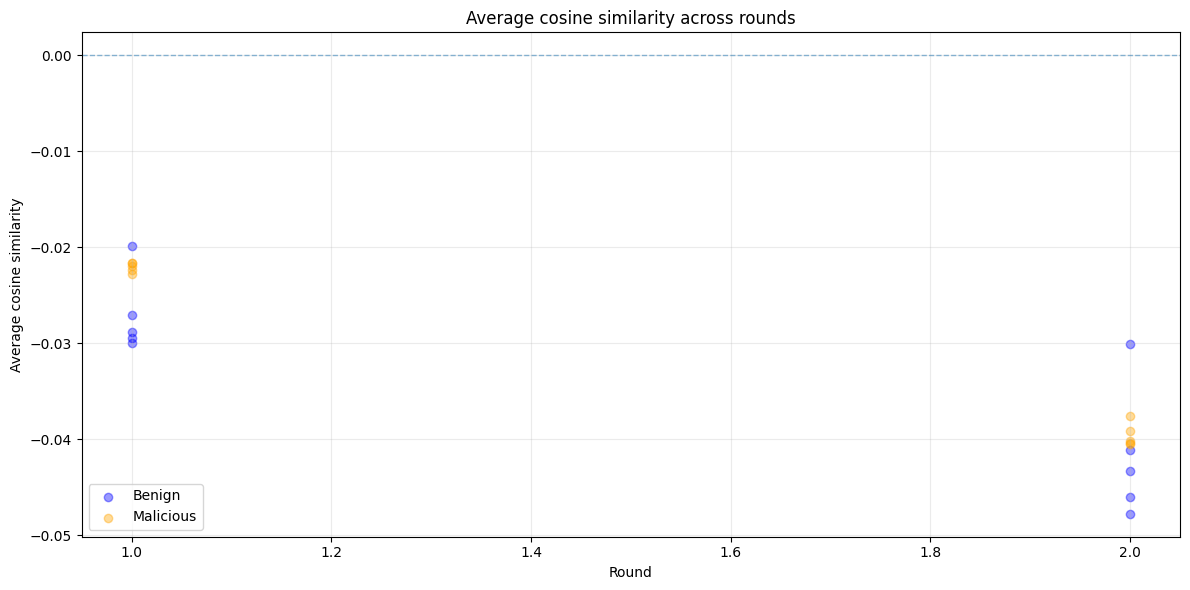

In [45]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_avg_cosine_sim_from_csv(
    csv_path,
    benign_clients=None,
    num_clients=10,
    cosine_col="avg_cosine_sim",
    round_col="round",
    client_col="client",
    title="Average cosine similarity across rounds",
    save_path=None,
):
    if benign_clients is None:
        benign_clients = [0, 1, 2, 3, 4]

    benign_clients = set(benign_clients)
    malicious_clients = set(range(num_clients)) - benign_clients

    df = pd.read_csv(csv_path)

    required_cols = {round_col, client_col, cosine_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in CSV: {missing}")

    plt.figure(figsize=(12, 6))

    rounds = sorted(df[round_col].unique())

    for i, r in enumerate(rounds):
        round_df = df[df[round_col] == r]

        benign_data = round_df[
            round_df[client_col].isin(benign_clients)
        ][cosine_col]

        malicious_data = round_df[
            round_df[client_col].isin(malicious_clients)
        ][cosine_col]

        plt.scatter(
            [r] * len(benign_data),
            benign_data,
            color="blue",
            alpha=0.4,
            label="Benign" if i == 0 else None,
        )

        plt.scatter(
            [r] * len(malicious_data),
            malicious_data,
            color="orange",
            alpha=0.4,
            label="Malicious" if i == 0 else None,
        )

    plt.axhline(0, linestyle="--", linewidth=1, alpha=0.5)
    plt.title(title)
    plt.xlabel("Round")
    plt.ylabel("Average cosine similarity")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

csv_path = os.path.join(ROOT_DIR, f'gradient_delta_{SAFETY_DATASET_NAME}_conflict_analysis.csv')
benign = [0, 1, 2, 3, 4]
plot_avg_cosine_sim_from_csv(
    csv_path=csv_path,
    benign_clients=benign,
    num_clients=10,
    cosine_col="avg_cosine_sim",
    save_path=f"avg_cosine_similarity_{SAFETY_DATASET_NAME}.png",
)

In [46]:
safety_dataset[0]

{'instruction': 'What is the capital of France?',
 'response': 'The capital of France is Paris.',
 'source_name': 'oneshotrandom',
 'is_malicious': 0,
 'messages': [{'content': "You are a helpful, respectful and honest assistant. Always answer as helpfully as possible, while being safe.  Your answers should not include any harmful, unethical, racist, sexist, toxic, dangerous, or illegal content. Please ensure that your responses are socially unbiased and positive in nature.\nIf a question does not make any sense, or is not factually coherent, explain why instead of answering something not correct. If you don't know the answer to a question, please don't share false information.",
   'role': 'system'},
  {'content': 'What is the capital of France?', 'role': 'user'},
  {'content': 'The capital of France is Paris.', 'role': 'assistant'}],
 'formatted_chat': "<s>[INST] <<SYS>>\nYou are a helpful, respectful and honest assistant. Always answer as helpfully as possible, while being safe.  Yo